In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install fastf1 tqdm --quiet
print('✅ Packages installed successfully')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.3 MB/s eta 0:00:00
✅ Packages installed successfully


In [3]:
import fastf1
import fastf1.plotting
import pandas as pd
import numpy as np
import os
import warnings
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

warnings.filterwarnings('ignore')

In [4]:
# ── CACHE SETUP ──────────────────────────────────────────────────────────────
# FastF1 downloads data once and caches it.
# On Kaggle, /kaggle/working is our writable directory.

CACHE_DIR  = '/kaggle/working/f1_cache'
OUTPUT_DIR = '/kaggle/working/data'

os.makedirs(CACHE_DIR,  exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

fastf1.Cache.enable_cache(CACHE_DIR)

print(f'✅ FastF1 version : {fastf1.__version__}')
print(f'📁 Cache directory : {CACHE_DIR}')
print(f'📁 Output directory: {OUTPUT_DIR}')

✅ FastF1 version : 3.8.1
📁 Cache directory : /kaggle/working/f1_cache
📁 Output directory: /kaggle/working/data


In [5]:
# ── RACE CONFIGURATION ───────────────────────────────────────────────────────
# Format: (year, round_number, grand_prix_name)
# We pick races with interesting strategy variety — different circuits,
# safety cars, undercuts, 1-stop vs 2-stop battles.

TRAINING_RACES = [
    # 2024 Season — Training Data
    (2024, 1,  'Bahrain'),       # Season opener, 2-stop typical
    (2024, 3,  'Australia'),     # Safety car chaos — great SC data
    (2024, 5,  'China'),         # Sprint weekend, unique strategy
    (2024, 7,  'Imola'),         # Classic undercut circuit
    (2024, 8,  'Monaco'),        # Track position everything, no overtaking
    (2024, 9,  'Canada'),        # Safety car likely, mixed strategy
    (2024, 11, 'Austria'),       # Sprint, aggressive tyre usage
    (2024, 12, 'Britain'),       # Mixed weather, strategy chaos
    (2024, 13, 'Hungary'),       # Overtaking hard, undercut critical
    (2024, 15, 'Netherlands'),   # Zandvoort — tyre management key
    (2024, 16, 'Monza'),         # Low deg, DRS heavy, slipstream
    (2024, 19, 'Singapore'),     # Street circuit, safety car likely
    (2024, 22, 'Abu Dhabi'),     # Season finale, clear racing
]

VALIDATION_RACES = [
    # 2025 Season — Validation / Backtest Data (NEVER seen during training)
    (2025, 1,  'Australia'),
    (2025, 2,  'China'),
    (2025, 3,  'Japan'),
    (2025, 4,  'Bahrain'),
    (2025, 5,  'Saudi Arabia'),
]

print(f'📊 Training races  : {len(TRAINING_RACES)} (2024 season)')
print(f'📊 Validation races: {len(VALIDATION_RACES)} (2025 season)')
print(f'📊 Total races     : {len(TRAINING_RACES) + len(VALIDATION_RACES)}')

📊 Training races  : 13 (2024 season)
📊 Validation races: 5 (2025 season)
📊 Total races     : 18


In [6]:
# ── DATA EXTRACTION FUNCTION ─────────────────────────────────────────────────

def extract_race_data(year: int, round_num: int, gp_name: str) -> dict:
    """
    Pull all relevant data for one race session.
    
    Returns a dict with:
        laps_df    : lap-by-lap data for all drivers
        weather_df : weather conditions per timestamp
        session    : raw FastF1 session object
        meta       : circuit metadata
    """
    print(f'\n🏎️  Loading {year} {gp_name} Grand Prix...')
    
    # ── Step 1: Load session ──────────────────────────────────────────────────
    # 'R' = Race session. Could also be 'Q' (Qualifying), 'FP1', 'FP2', 'FP3'
    session = fastf1.get_session(year, round_num, 'R')
    
    # load() downloads: laps, telemetry, weather, track status
    # telemetry=False speeds things up — we add it later per-driver
    session.load(telemetry=False, weather=True, messages=True)
    
    print(f'   ✅ Session loaded: {session.event["EventName"]} — {session.date.strftime("%d %b %Y")}')
    print(f'   📍 Circuit: {session.event["Location"]}, {session.event["Country"]}')

    # ── Step 2: Extract lap data ──────────────────────────────────────────────
    # session.laps gives us a DataFrame with every lap from every driver
    laps = session.laps.copy()
    
    # Add identifying metadata columns
    laps['Year']       = year
    laps['RoundNum']   = round_num
    laps['GrandPrix']  = gp_name
    laps['Circuit']    = session.event['Location']
    laps['Country']    = session.event['Country']
    laps['TotalLaps']  = laps['LapNumber'].max()
    
    # Convert lap time from timedelta to seconds (float) — models need numbers
    laps['LapTimeSec'] = laps['LapTime'].dt.total_seconds()
    
    # ── Step 3: Tyre stint engineering ───────────────────────────────────────
    # TyreLife = how many laps on current set (FastF1 provides this)
    # We also compute StintNumber ourselves as a cross-check
    
    laps['StintNumber'] = (
        laps.groupby('Driver')['Stint'].transform(lambda x: x)
    )
    
    # ── Step 4: Pit lap flags ─────────────────────────────────────────────────
    # PitInTime / PitOutTime are not null when a driver pits on that lap.
    # This becomes our LABEL — did the driver pit on this lap?
    laps['DidPit'] = laps['PitInTime'].notna().astype(int)
    
    # ── Step 5: Gap to leader ─────────────────────────────────────────────────
    # FastF1 gives Position per lap. We compute gap ourselves later
    # during feature engineering. For now just keep Position.
    
    # ── Step 6: Track status per lap ─────────────────────────────────────────
    # Track status codes: 1=Clear, 2=Yellow, 4=SC, 5=Red, 6=VSC, 7=SC ending
    # We'll map each lap to the most common track status during that lap
    
    try:
        track_status = session.track_status
        # Get safety car laps
        sc_laps = set()
        vsc_laps = set()
        if track_status is not None and len(track_status) > 0:
            # Status '4' = Safety Car, '6' = Virtual Safety Car
            sc_periods  = track_status[track_status['Status'] == '4']
            vsc_periods = track_status[track_status['Status'] == '6']
            
            # Map periods to lap numbers (approximate using time)
            for _, row in sc_periods.iterrows():
                lap_match = laps[
                    (laps['LapStartTime'] <= row['Time']) &
                    (laps['LapStartTime'] + laps['LapTime'] >= row['Time'])
                ]
                sc_laps.update(lap_match['LapNumber'].tolist())
        
        laps['SafetyCarLap'] = laps['LapNumber'].isin(sc_laps).astype(int)
        laps['VSCLap']       = laps['LapNumber'].isin(vsc_laps).astype(int)
        print(f'   🟡 Safety car laps detected: {len(sc_laps)}')
    except Exception as e:
        laps['SafetyCarLap'] = 0
        laps['VSCLap']       = 0
        print(f'   ⚠️  Track status unavailable: {e}')
    
    # ── Step 7: Select and clean columns we need ──────────────────────────────
    KEEP_COLS = [
        # Identity
        'Year', 'RoundNum', 'GrandPrix', 'Circuit', 'Country',
        # Driver info
        'Driver', 'DriverNumber', 'Team',
        # Lap info
        'LapNumber', 'TotalLaps', 'LapTimeSec', 'IsPersonalBest',
        # Tyre
        'Compound', 'TyreLife', 'FreshTyre', 'StintNumber',
        # Race context
        'Position', 'DidPit',
        # Track events
        'SafetyCarLap', 'VSCLap',
        # Timing
        'LapStartTime',
    ]
    
    # Only keep columns that exist (some may be missing in older seasons)
    available_cols = [c for c in KEEP_COLS if c in laps.columns]
    laps_clean = laps[available_cols].copy()
    
    # Drop laps with no valid lap time (in-laps, outlaps are often NaN)
    laps_clean = laps_clean.dropna(subset=['LapTimeSec'])
    
    # Remove obvious outliers (laps > 3x the median — usually SC/red flag)
    median_laptime = laps_clean['LapTimeSec'].median()
    laps_clean = laps_clean[laps_clean['LapTimeSec'] < median_laptime * 2.5]
    
    # ── Step 8: Weather data ──────────────────────────────────────────────────
    try:
        weather = session.weather_data.copy()
        weather['GrandPrix'] = gp_name
        weather['Year']      = year
        weather_clean = weather[[
            'Year', 'GrandPrix', 'Time', 'AirTemp', 'TrackTemp',
            'Humidity', 'Pressure', 'WindSpeed', 'Rainfall'
        ]].copy()
        print(f'   🌤️  Weather records: {len(weather_clean)}')
    except Exception as e:
        weather_clean = pd.DataFrame()
        print(f'   ⚠️  Weather unavailable: {e}')
    
    # ── Step 9: Circuit metadata ──────────────────────────────────────────────
    meta = {
        'year'         : year,
        'round'        : round_num,
        'grand_prix'   : gp_name,
        'circuit'      : session.event['Location'],
        'country'      : session.event['Country'],
        'total_laps'   : int(laps_clean['LapNumber'].max()),
        'num_drivers'  : laps_clean['Driver'].nunique(),
        'sc_laps'      : int(laps_clean['SafetyCarLap'].sum()),
        'median_laptime': round(median_laptime, 3),
    }
    
    print(f'   📊 Laps extracted: {len(laps_clean)} across {meta["num_drivers"]} drivers')
    print(f'   ⏱️  Median lap time: {median_laptime:.3f}s')
    
    return {
        'laps'    : laps_clean,
        'weather' : weather_clean,
        'session' : session,
        'meta'    : meta
    }

print('✅ extract_race_data() function defined — ready to pull data')

✅ extract_race_data() function defined — ready to pull data


In [7]:
# ── RUN PIPELINE — TRAINING DATA ─────────────────────────────────────────────

all_laps    = []   # will collect lap DataFrames from all races
all_weather = []   # will collect weather DataFrames
all_meta    = []   # will collect metadata dicts
failed      = []   # track any races that fail

print('=' * 60)
print('🏁 STARTING DATA PIPELINE — TRAINING RACES (2024)')
print('=' * 60)

for year, round_num, gp_name in tqdm(TRAINING_RACES, desc='Racing through 2024...'):
    try:
        result = extract_race_data(year, round_num, gp_name)
        all_laps.append(result['laps'])
        if len(result['weather']) > 0:
            all_weather.append(result['weather'])
        all_meta.append(result['meta'])
    except Exception as e:
        print(f'\n❌ Failed: {year} {gp_name} — {e}')
        failed.append((year, gp_name, str(e)))
        continue

print('\n' + '=' * 60)
print(f'✅ PIPELINE COMPLETE')
print(f'   Races loaded : {len(all_meta)}/{len(TRAINING_RACES)}')
if failed:
    print(f'   Failed       : {[f"{y} {g}" for y,g,_ in failed]}')
print('=' * 60)

🏁 STARTING DATA PIPELINE — TRAINING RACES (2024)


Racing through 2024...:   0%|          | 0/13 [00:00<?, ?it/s]


🏎️  Loading 2024 Bahrain Grand Prix...


core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No ca

   ✅ Session loaded: Bahrain Grand Prix — 02 Mar 2024
   📍 Circuit: Sakhir, Bahrain
   🟡 Safety car laps detected: 0
   🌤️  Weather records: 157
   📊 Laps extracted: 1127 across 20 drivers
   ⏱️  Median lap time: 97.046s

🏎️  Loading 2024 Australia Grand Prix...


...

   ✅ Session loaded: Italian Grand Prix — 01 Sep 2024
   📍 Circuit: Monza, Italy
   🟡 Safety car laps detected: 0
   🌤️  Weather records: 133
   📊 Laps extracted: 1008 across 20 drivers
   ⏱️  Median lap time: 84.981s

🏎️  Loading 2024 Singapore Grand Prix...


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
_api        WARNING 	Failed to align laps for driver

   ✅ Session loaded: United States Grand Prix — 20 Oct 2024
   📍 Circuit: Austin, United States
   🟡 Safety car laps detected: 1
   🌤️  Weather records: 155
   📊 Laps extracted: 1031 across 20 drivers
   ⏱️  Median lap time: 100.338s

🏎️  Loading 2024 Abu Dhabi Grand Prix...


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!

   ✅ Session loaded: Las Vegas Grand Prix — 24 Nov 2024
   📍 Circuit: Las Vegas, United States
   🟡 Safety car laps detected: 0
   🌤️  Weather records: 143
   📊 Laps extracted: 938 across 20 drivers
   ⏱️  Median lap time: 98.628s

✅ PIPELINE COMPLETE
   Races loaded : 13/13


In [8]:
# ── RUN PIPELINE — VALIDATION DATA ───────────────────────────────────────────

val_laps    = []
val_weather = []
val_meta    = []

print('=' * 60)
print('🏁 STARTING DATA PIPELINE — VALIDATION RACES (2025)')
print('=' * 60)

for year, round_num, gp_name in tqdm(VALIDATION_RACES, desc='Racing through 2025...'):
    try:
        result = extract_race_data(year, round_num, gp_name)
        val_laps.append(result['laps'])
        if len(result['weather']) > 0:
            val_weather.append(result['weather'])
        val_meta.append(result['meta'])
    except Exception as e:
        print(f'\n❌ Failed: {year} {gp_name} — {e}')
        continue

print('\n' + '=' * 60)
print(f'✅ VALIDATION PIPELINE COMPLETE — {len(val_meta)}/{len(VALIDATION_RACES)} races')
print('=' * 60)

🏁 STARTING DATA PIPELINE — VALIDATION RACES (2025)


Racing through 2025...:   0%|          | 0/5 [00:00<?, ?it/s]core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...



🏎️  Loading 2025 Australia Grand Prix...


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!

   ✅ Session loaded: Australian Grand Prix — 16 Mar 2025
   📍 Circuit: Melbourne, Australia
   🟡 Safety car laps detected: 5
   🌤️  Weather records: 178
   📊 Laps extracted: 858 across 17 drivers
   ⏱️  Median lap time: 93.499s

🏎️  Loading 2025 China Grand Prix...


...

   ✅ Session loaded: Japanese Grand Prix — 06 Apr 2025
   📍 Circuit: Suzuka, Japan
   🟡 Safety car laps detected: 0
   🌤️  Weather records: 140
   📊 Laps extracted: 1059 across 20 drivers
   ⏱️  Median lap time: 93.367s

🏎️  Loading 2025 Bahrain Grand Prix...


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!

   ✅ Session loaded: Bahrain Grand Prix — 13 Apr 2025
   📍 Circuit: Sakhir, Bahrain
   🟡 Safety car laps detected: 1
   🌤️  Weather records: 158
   📊 Laps extracted: 1115 across 20 drivers
   ⏱️  Median lap time: 98.593s

🏎️  Loading 2025 Saudi Arabia Grand Prix...


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
_api        WARNING 	Failed to align laps for driver

   ✅ Session loaded: Saudi Arabian Grand Prix — 20 Apr 2025
   📍 Circuit: Jeddah, Saudi Arabia
   🟡 Safety car laps detected: 1
   🌤️  Weather records: 142
   📊 Laps extracted: 861 across 19 drivers
   ⏱️  Median lap time: 94.466s

✅ VALIDATION PIPELINE COMPLETE — 5/5 races


In [9]:
# ── COMBINE ALL RACES ─────────────────────────────────────────────────────────

# Training data
train_df = pd.concat(all_laps, ignore_index=True)
train_df = train_df.sort_values(['Year','RoundNum','LapNumber','Driver']).reset_index(drop=True)

# Validation data
val_df = pd.concat(val_laps, ignore_index=True) if val_laps else pd.DataFrame()
if len(val_df): 
    val_df = val_df.sort_values(['Year','RoundNum','LapNumber','Driver']).reset_index(drop=True)

# Weather combined
weather_df = pd.concat(all_weather + val_weather, ignore_index=True) if (all_weather or val_weather) else pd.DataFrame()

# Circuit metadata
meta_df = pd.DataFrame(all_meta + val_meta)

# ── SAVE TO CSV ───────────────────────────────────────────────────────────────
train_df.to_csv(f'{OUTPUT_DIR}/train_laps.csv',   index=False)
val_df.to_csv(  f'{OUTPUT_DIR}/val_laps.csv',     index=False)
meta_df.to_csv( f'{OUTPUT_DIR}/circuit_meta.csv', index=False)
if len(weather_df):
    weather_df.to_csv(f'{OUTPUT_DIR}/weather.csv', index=False)

print('📁 FILES SAVED:')
print(f'   train_laps.csv   → {len(train_df):,} rows  ({train_df["GrandPrix"].nunique()} races)')
print(f'   val_laps.csv     → {len(val_df):,} rows  ({val_df["GrandPrix"].nunique() if len(val_df) else 0} races)')
print(f'   circuit_meta.csv → {len(meta_df)} circuits')
if len(weather_df):
    print(f'   weather.csv      → {len(weather_df):,} rows')

print('\n📊 TRAINING DATA OVERVIEW:')
print(train_df.info())

📁 FILES SAVED:
   train_laps.csv   → 14,966 rows  (13 races)
   val_laps.csv     → 4,958 rows  (5 races)
   circuit_meta.csv → 18 circuits
   weather.csv      → 2,723 rows

📊 TRAINING DATA OVERVIEW:
<class 'fastf1.core.Laps'>
RangeIndex: 14966 entries, 0 to 14965
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype          
---  ------          --------------  -----          
 0   Year            14966 non-null  int64          
 1   RoundNum        14966 non-null  int64          
 2   GrandPrix       14966 non-null  object         
 3   Circuit         14966 non-null  object         
 4   Country         14966 non-null  object         
 5   Driver          14966 non-null  object         
 6   DriverNumber    14966 non-null  object         
 7   Team            14966 non-null  object         
 8   LapNumber       14966 non-null  float64        
 9   TotalLaps       14966 non-null  float64        
 10  LapTimeSec      14966 non-null  float64        
 11  IsPersona

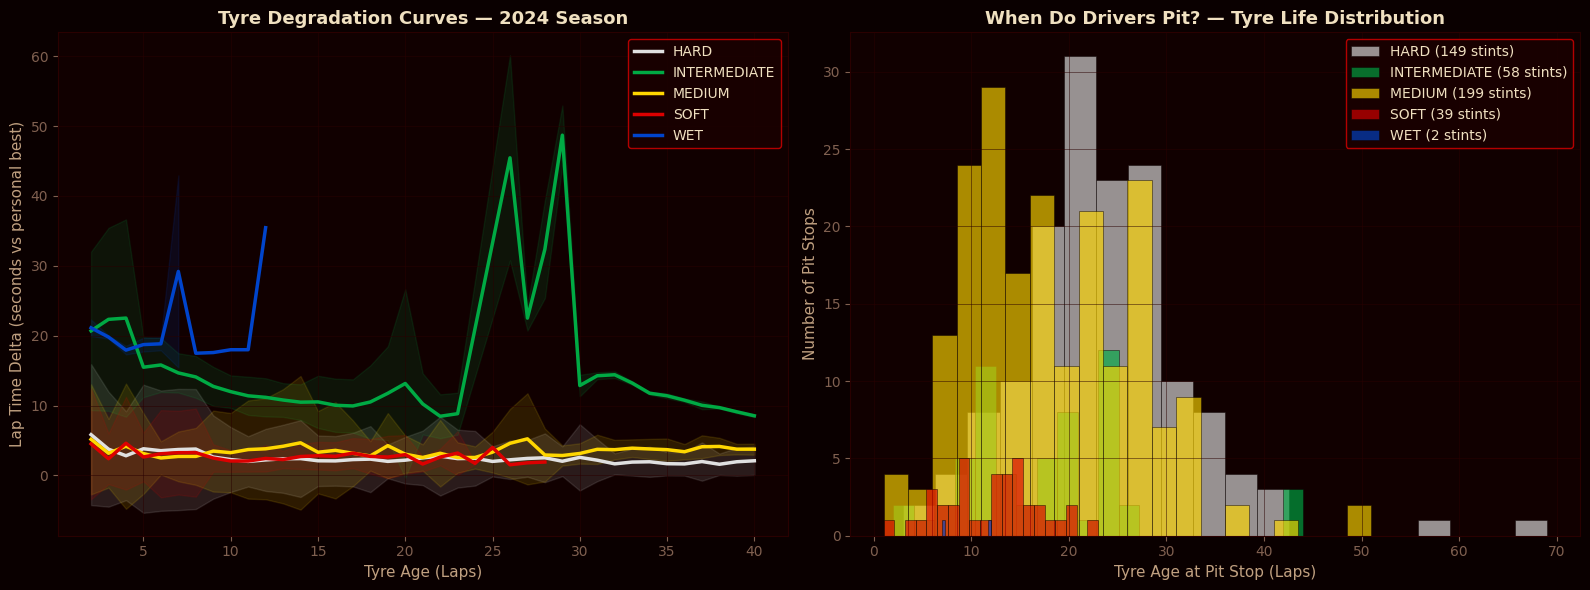

✅ Plot saved to: /kaggle/working/data/eda_tyre_degradation.png


In [10]:
# ── PLOT 1: TYRE DEGRADATION CURVES ──────────────────────────────────────────
# Filter: remove safety car laps (they distort lap times)
# Filter: only racing laps (TyreLife > 1 to skip out-laps)

clean_laps = train_df[
    (train_df['SafetyCarLap'] == 0) &
    (train_df['VSCLap']       == 0) &
    (train_df['TyreLife']      > 1) &
    (train_df['LapTimeSec'].notna())
].copy()

# Normalize lap time: delta from each driver's personal best that race
# This removes circuit differences — we want DEGRADATION, not circuit effect
clean_laps['LapTimeDelta'] = clean_laps.groupby(['GrandPrix','Driver'])['LapTimeSec'].transform(
    lambda x: x - x.min()
)

# Average degradation per compound per tyre age
deg_curve = clean_laps.groupby(['Compound','TyreLife'])['LapTimeDelta'].agg(['mean','std']).reset_index()
deg_curve.columns = ['Compound','TyreLife','MeanDelta','StdDelta']
deg_curve = deg_curve[deg_curve['TyreLife'] <= 40]  # cap at 40 laps for visibility

# ── PLOT ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0A0000')

compound_colors = {'SOFT':'#DC0000', 'MEDIUM':'#FFD700', 'HARD':'#E0E0E0', 'INTERMEDIATE':'#00AA44', 'WET':'#0044CC'}

ax1 = axes[0]
ax1.set_facecolor('#110000')
ax1.grid(color='#2A0000', linewidth=0.5, alpha=0.7)

for compound, grp in deg_curve.groupby('Compound'):
    color = compound_colors.get(compound, '#888888')
    ax1.plot(grp['TyreLife'], grp['MeanDelta'], color=color, linewidth=2.5, label=compound)
    ax1.fill_between(grp['TyreLife'],
                     grp['MeanDelta'] - grp['StdDelta'],
                     grp['MeanDelta'] + grp['StdDelta'],
                     color=color, alpha=0.12)

ax1.set_xlabel('Tyre Age (Laps)', color='#C0A080', fontsize=11)
ax1.set_ylabel('Lap Time Delta (seconds vs personal best)', color='#C0A080', fontsize=11)
ax1.set_title('Tyre Degradation Curves — 2024 Season', color='#F0E0C0', fontsize=13, fontweight='bold')
ax1.tick_params(colors='#806050')
ax1.legend(facecolor='#1A0000', edgecolor='#DC0000', labelcolor='#F0E0C0')
for spine in ax1.spines.values(): spine.set_color('#2A0000')

# ── PLOT 2: Pit stop distribution ────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor('#110000')
ax2.grid(color='#2A0000', linewidth=0.5, alpha=0.7)

pit_laps = train_df[train_df['DidPit'] == 1].copy()
pit_laps['LapPct'] = pit_laps['LapNumber'] / pit_laps['TotalLaps'] * 100

for compound, grp in pit_laps.groupby('Compound'):
    color = compound_colors.get(compound, '#888888')
    ax2.hist(grp['TyreLife'], bins=20, color=color, alpha=0.65,
             label=f'{compound} ({len(grp)} stints)', edgecolor='#0A0000', linewidth=0.5)

ax2.set_xlabel('Tyre Age at Pit Stop (Laps)', color='#C0A080', fontsize=11)
ax2.set_ylabel('Number of Pit Stops', color='#C0A080', fontsize=11)
ax2.set_title('When Do Drivers Pit? — Tyre Life Distribution', color='#F0E0C0', fontsize=13, fontweight='bold')
ax2.tick_params(colors='#806050')
ax2.legend(facecolor='#1A0000', edgecolor='#DC0000', labelcolor='#F0E0C0')
for spine in ax2.spines.values(): spine.set_color('#2A0000')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_tyre_degradation.png', dpi=150, bbox_inches='tight', facecolor='#0A0000')
plt.show()
print('✅ Plot saved to:', f'{OUTPUT_DIR}/eda_tyre_degradation.png')

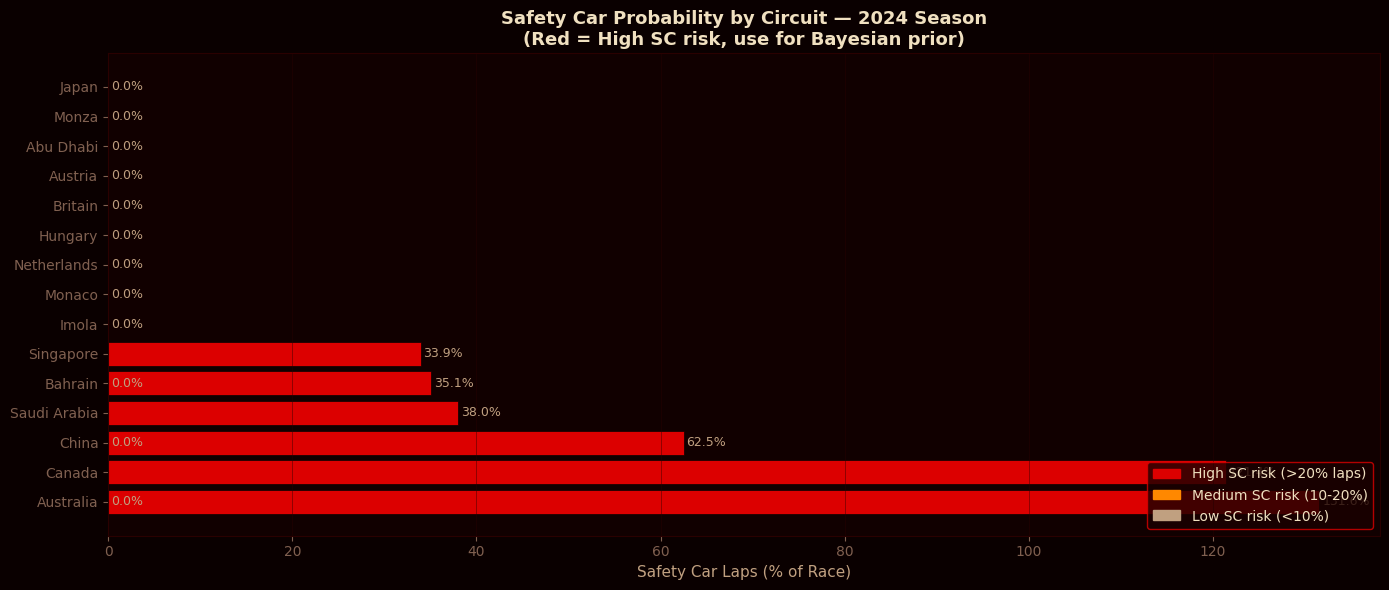


📊 CIRCUIT SC RATES (top 5):
  grand_prix  total_laps  sc_laps     SCRate
   Australia          57       75 131.578947
      Canada          70       85 121.428571
       China          56       35  62.500000
Saudi Arabia          50       19  38.000000
     Bahrain          57       20  35.087719


In [11]:
# ── SAFETY CAR RATE PER CIRCUIT ───────────────────────────────────────────────

sc_analysis = meta_df.copy()
sc_analysis['SCRate'] = sc_analysis['sc_laps'] / sc_analysis['total_laps'] * 100
sc_analysis = sc_analysis.sort_values('SCRate', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0A0000')
ax.set_facecolor('#110000')
ax.grid(color='#2A0000', linewidth=0.5, alpha=0.6, axis='x')

colors = ['#DC0000' if r > 20 else '#FF8800' if r > 10 else '#C0A080'
          for r in sc_analysis['SCRate']]

bars = ax.barh(sc_analysis['grand_prix'], sc_analysis['SCRate'],
               color=colors, edgecolor='#0A0000', linewidth=0.5)

for bar, val in zip(bars, sc_analysis['SCRate']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', color='#C0A080', fontsize=9)

ax.set_xlabel('Safety Car Laps (% of Race)', color='#C0A080', fontsize=11)
ax.set_title('Safety Car Probability by Circuit — 2024 Season\n(Red = High SC risk, use for Bayesian prior)', 
             color='#F0E0C0', fontsize=13, fontweight='bold')
ax.tick_params(colors='#806050')
for spine in ax.spines.values(): spine.set_color('#2A0000')

# Add legend
patches = [
    mpatches.Patch(color='#DC0000', label='High SC risk (>20% laps)'),
    mpatches.Patch(color='#FF8800', label='Medium SC risk (10-20%)'),
    mpatches.Patch(color='#C0A080', label='Low SC risk (<10%)'),
]
ax.legend(handles=patches, facecolor='#1A0000', edgecolor='#DC0000', labelcolor='#F0E0C0', loc='lower right')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_safety_car.png', dpi=150, bbox_inches='tight', facecolor='#0A0000')
plt.show()

print('\n📊 CIRCUIT SC RATES (top 5):')
print(sc_analysis[['grand_prix','total_laps','sc_laps','SCRate']].head().to_string(index=False))

In [12]:
# ── FERRARI STRATEGY ANALYSIS ─────────────────────────────────────────────────

ferrari_laps = train_df[
    train_df['Team'].str.contains('Ferrari', case=False, na=False)
].copy()

ferrari_pits = ferrari_laps[ferrari_laps['DidPit'] == 1].copy()

print('🔴 FERRARI 2024 STRATEGY OVERVIEW')
print('=' * 50)
print(f'Total laps analysed : {len(ferrari_laps):,}')
print(f'Total pit stops     : {len(ferrari_pits)}')
print(f'Drivers             : {ferrari_laps["Driver"].unique()}')
print()

# Pit stop timing per race
ferrari_pits_summary = ferrari_pits.groupby(['GrandPrix','Driver']).agg(
    PitLaps   = ('LapNumber', list),
    TyreAges  = ('TyreLife',  list),
    Compounds = ('Compound',  list),
    NumPits   = ('DidPit',    'sum')
).reset_index()

print('📊 PIT STOP SUMMARY PER RACE:')
print(ferrari_pits_summary[['GrandPrix','Driver','NumPits','PitLaps','TyreAges']].to_string(index=False))

# Average tyre age at pit stop per compound
print('\n📊 AVERAGE TYRE AGE AT PIT STOP (Ferrari 2024):')
print(ferrari_pits.groupby('Compound')['TyreLife'].agg(['mean','min','max','count']).round(1))

🔴 FERRARI 2024 STRATEGY OVERVIEW
Total laps analysed : 1,550
Total pit stops     : 43
Drivers             : ['LEC' 'SAI']

📊 PIT STOP SUMMARY PER RACE:
  GrandPrix Driver  NumPits                 PitLaps                TyreAges
  Abu Dhabi    LEC        2             [9.0, 31.0]             [9.0, 22.0]
  Abu Dhabi    SAI        2            [10.0, 28.0]            [10.0, 18.0]
  Australia    LEC        2             [9.0, 34.0]             [9.0, 25.0]
  Australia    SAI        2            [16.0, 41.0]            [16.0, 25.0]
    Austria    LEC        4 [1.0, 16.0, 33.0, 51.0] [1.0, 15.0, 17.0, 19.0]
    Austria    SAI        2            [22.0, 47.0]            [22.0, 25.0]
    Bahrain    LEC        2            [11.0, 34.0]            [14.0, 23.0]
    Bahrain    SAI        2            [14.0, 35.0]            [17.0, 21.0]
    Britain    LEC        3      [19.0, 27.0, 37.0]       [19.0, 8.0, 10.0]
    Britain    SAI        3      [26.0, 39.0, 50.0]      [26.0, 13.0, 11.0]
     Canada 

In [13]:
# ── DATA QUALITY REPORT ───────────────────────────────────────────────────────

print('🔍 DATA QUALITY REPORT')
print('=' * 50)

for name, df in [('TRAIN', train_df), ('VAL', val_df)]:
    if len(df) == 0:
        continue
    print(f'\n[{name}] Shape: {df.shape}')
    print(f'  Races     : {df["GrandPrix"].nunique()}')
    print(f'  Drivers   : {df["Driver"].nunique()}')
    print(f'  Compounds : {df["Compound"].value_counts().to_dict()}')
    print(f'  Pit stops : {df["DidPit"].sum()} ({df["DidPit"].mean()*100:.1f}% of laps)')
    print(f'  SC laps   : {df["SafetyCarLap"].sum()} ({df["SafetyCarLap"].mean()*100:.1f}% of laps)')

    # Null check
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if len(nulls):
        print(f'  ⚠️  Nulls  :')
        for col, n in nulls.items():
            print(f'     {col}: {n} ({n/len(df)*100:.1f}%)')
    else:
        print('  ✅ No null values in key columns')

print('\n' + '=' * 50)
print('✅ DATA PIPELINE COMPLETE — Ready for Notebook 2: Feature Engineering')
print('\n📁 Output files in /kaggle/working/data/')
print('   → train_laps.csv   (2024 training data)')
print('   → val_laps.csv     (2025 validation data)')
print('   → circuit_meta.csv (circuit-level stats)')
print('   → weather.csv      (session weather data)')
print('\n🏎️  NEXT: Notebook 2 — Feature Engineering (tyre deg, gaps, SC probability)')

🔍 DATA QUALITY REPORT

[TRAIN] Shape: (14966, 21)
  Races     : 13
  Drivers   : 22
  Compounds : {'HARD': 8214, 'MEDIUM': 4839, 'INTERMEDIATE': 1059, 'SOFT': 835, 'WET': 19}
  Pit stops : 447 (3.0% of laps)
  SC laps   : 139 (0.9% of laps)
  ✅ No null values in key columns

[VAL] Shape: (4958, 21)
  Races     : 5
  Drivers   : 20
  Compounds : {'HARD': 2311, 'MEDIUM': 1600, 'INTERMEDIATE': 692, 'SOFT': 355}
  Pit stops : 137 (2.8% of laps)
  SC laps   : 114 (2.3% of laps)
  ⚠️  Nulls  :
     TyreLife: 5 (0.1%)

✅ DATA PIPELINE COMPLETE — Ready for Notebook 2: Feature Engineering

📁 Output files in /kaggle/working/data/
   → train_laps.csv   (2024 training data)
   → val_laps.csv     (2025 validation data)
   → circuit_meta.csv (circuit-level stats)
   → weather.csv      (session weather data)

🏎️  NEXT: Notebook 2 — Feature Engineering (tyre deg, gaps, SC probability)
